# Week 2 — Exploratory Data Analysis (EDA)


## Step 1 — Load Qinyao's already-collected data

Her `00_collect_datasets_colab.ipynb` downloads and standardizes all three datasets into JSONL files under:

```
/content/drive/MyDrive/AAI590/data/processed/{conll2003,wnut17,scierc}/
```

Run that notebook first (or get access to her Drive folder) so the files below are found.


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROCESSED = Path('/content/drive/MyDrive/AAI590/data/processed')

for name in ['conll2003', 'wnut17', 'scierc']:
    d = PROCESSED / name
    print(name, '->', sorted(p.name for p in d.glob('*')) if d.exists() else 'NOT FOUND YET')


Mounted at /content/drive
conll2003 -> ['conll2003_test.jsonl', 'conll2003_train.jsonl', 'conll2003_validation.jsonl', 'summary.json']
wnut17 -> ['summary.json', 'wnut17_test.jsonl', 'wnut17_train.jsonl', 'wnut17_validation.jsonl']
scierc -> ['scierc_test.jsonl', 'scierc_train.jsonl', 'scierc_validation.jsonl', 'summary.json']


In [2]:
import json

def load_jsonl_pairs(path):
    """Reads one of Qinyao's processed .jsonl files and returns a list of (tokens, tags)."""
    pairs = []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            pairs.append((row["tokens"], row["tags"]))
    return pairs

def load_dataset_pairs(dataset_name, splits=("train", "validation", "test")):
    all_pairs = []
    d = PROCESSED / dataset_name
    for split in splits:
        fp = d / f"{dataset_name}_{split}.jsonl"
        if fp.exists():
            all_pairs.extend(load_jsonl_pairs(fp))
        else:
            print(f"  (skipping {fp.name} -- not found)")
    return all_pairs

conll_pairs = load_dataset_pairs("conll2003")
wnut_pairs = load_dataset_pairs("wnut17")
scierc_pairs = load_dataset_pairs("scierc")

print("CoNLL-2003 sentences:", len(conll_pairs))
print("WNUT17 sentences:", len(wnut_pairs))
print("SciERC sentences:", len(scierc_pairs))

print("\nExample CoNLL-2003 sentence:")
tokens, tags = conll_pairs[0]
print("Tokens:", tokens)
print("Tags:", tags)


CoNLL-2003 sentences: 20744
WNUT17 sentences: 5690
SciERC sentences: 2687

Example CoNLL-2003 sentence:
Tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Tags: ['I-ORG', 'O', 'I-MISC', 'O', 'O', 'O', 'I-MISC', 'O', 'O']


## Step 2 — Put every dataset into one common set of statistics



In [3]:
from collections import Counter

def entity_type_of(tag):
    return tag.split("-", 1)[1] if "-" in tag else tag

def dataset_stats(name, pairs):
    n_sentences = len(pairs)
    all_tokens = [tok for tokens, _ in pairs for tok in tokens]
    n_tokens = len(all_tokens)
    avg_len = n_tokens / n_sentences
    vocab = set(tok.lower() for tok in all_tokens)

    entity_type_counts = Counter()
    n_entity_tokens = 0
    for _, tags in pairs:
        prev_tag = "O"
        for tag in tags:
            if tag != "O":
                n_entity_tokens += 1
                starts_new_entity = (
                    tag.startswith("B-")
                    or prev_tag == "O"
                    or entity_type_of(prev_tag) != entity_type_of(tag)
                )
                if starts_new_entity:
                    entity_type_counts[entity_type_of(tag)] += 1
            prev_tag = tag

    return {
        "name": name,
        "n_sentences": n_sentences,
        "n_tokens": n_tokens,
        "avg_sentence_len": round(avg_len, 1),
        "vocab_size": len(vocab),
        "pct_tokens_entity": round(100 * n_entity_tokens / n_tokens, 1),
        "entity_type_counts": dict(entity_type_counts),
        "vocab_set": vocab,
    }

conll_stats = dataset_stats("CoNLL-2003", conll_pairs)
wnut_stats = dataset_stats("WNUT17", wnut_pairs)
scierc_stats = dataset_stats("SciERC", scierc_pairs)

for s in (conll_stats, wnut_stats, scierc_stats):
    total_entities = sum(s["entity_type_counts"].values())
    print(s["name"], "-> sentences:", s["n_sentences"], "| tokens:", s["n_tokens"],
          "| avg sentence length:", s["avg_sentence_len"],
          "| vocab size:", s["vocab_size"],
          "| % tokens that are an entity:", s["pct_tokens_entity"],
          "| total entities found:", total_entities)


CoNLL-2003 -> sentences: 20744 | tokens: 301418 | avg sentence length: 14.5 | vocab size: 26869 | % tokens that are an entity: 16.8 | total entities found: 35089
WNUT17 -> sentences: 5690 | tokens: 101857 | avg sentence length: 17.9 | vocab size: 17831 | % tokens that are an entity: 6.0 | total entities found: 3890
SciERC -> sentences: 2687 | tokens: 65334 | avg sentence length: 24.3 | vocab size: 6634 | % tokens that are an entity: 28.9 | total entities found: 8084


## Step 3 — Table + entity-type charts

Two versions of the entity-type chart: **raw counts** (useful to see absolute scale) and **share within each dataset** (useful for comparing *shape* of the label distribution fairly, since CoNLL-2003 has roughly 8x more sentences than SciERC and 4x more than WNUT17 — raw counts alone make the smaller datasets look emptier than they really are, relatively speaking).


In [4]:
import pandas as pd

summary_df = pd.DataFrame([
    {
        "Dataset": s["name"],
        "Sentences": s["n_sentences"],
        "Tokens": s["n_tokens"],
        "Avg. sentence length": s["avg_sentence_len"],
        "Vocabulary size": s["vocab_size"],
        "% tokens tagged as an entity": s["pct_tokens_entity"],
    }
    for s in (conll_stats, wnut_stats, scierc_stats)
])
summary_df


,Dataset,Sentences,Tokens,Avg. sentence length,Vocabulary size,% tokens tagged as an entity
0,CoNLL-2003,20744,301418,14.5,26869,16.8
1,WNUT17,5690,101857,17.9,17831,6.0
2,SciERC,2687,65334,24.3,6634,28.9


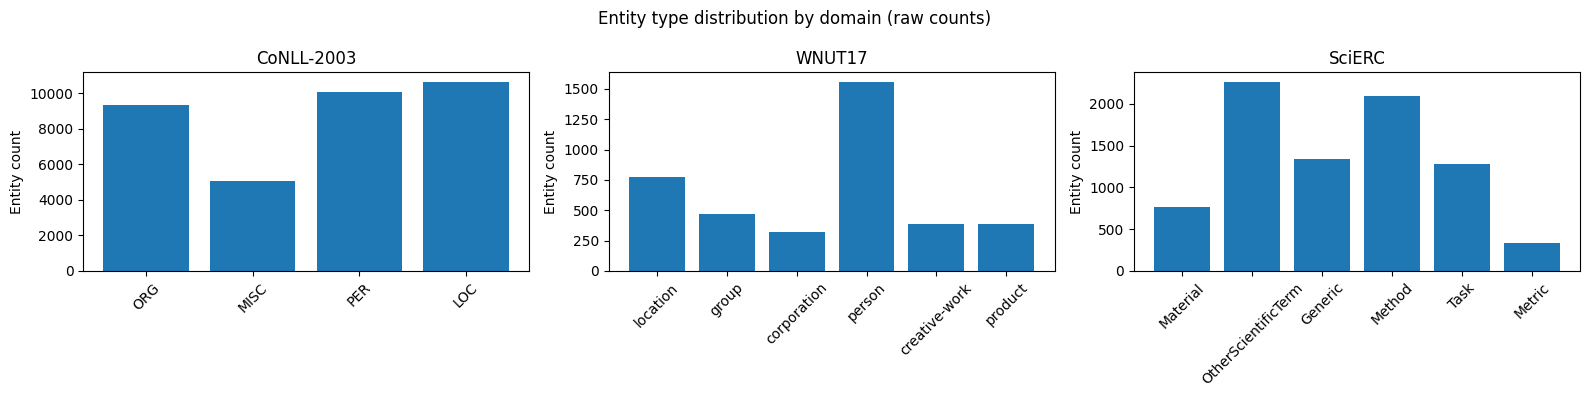

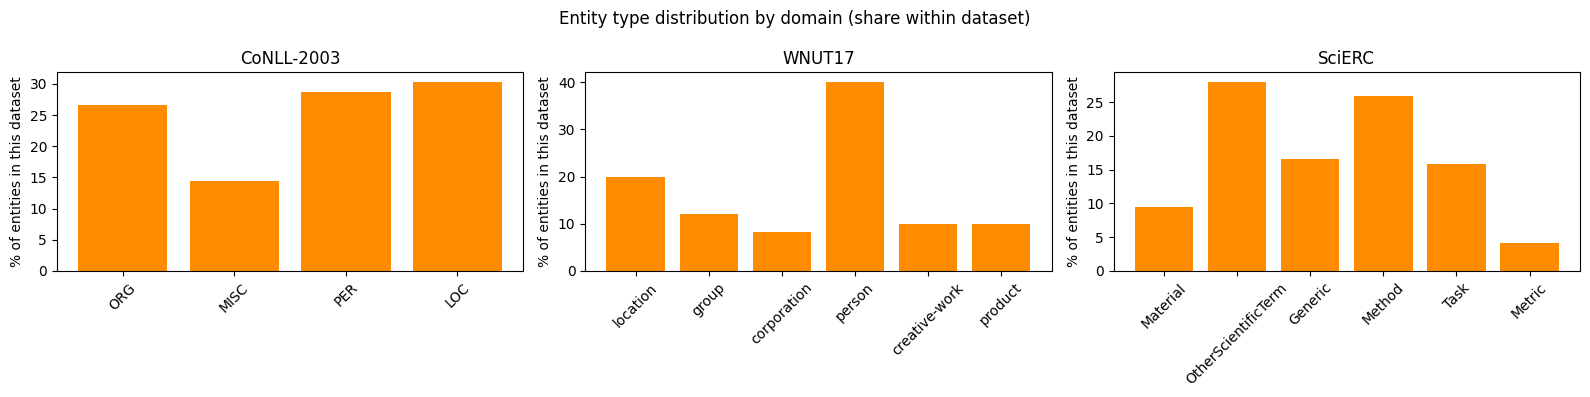

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, s in zip(axes, (conll_stats, wnut_stats, scierc_stats)):
    counts = s["entity_type_counts"]
    ax.bar(list(counts.keys()), list(counts.values()))
    ax.set_title(s["name"])
    ax.set_ylabel("Entity count")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Entity type distribution by domain (raw counts)")
fig.tight_layout()
plt.savefig("entity_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
for ax, s in zip(axes2, (conll_stats, wnut_stats, scierc_stats)):
    counts = s["entity_type_counts"]
    total = sum(counts.values())
    shares = {k: 100 * v / total for k, v in counts.items()}
    ax.bar(list(shares.keys()), list(shares.values()), color="darkorange")
    ax.set_title(s["name"])
    ax.set_ylabel("% of entities in this dataset")
    ax.tick_params(axis="x", rotation=45)
fig2.suptitle("Entity type distribution by domain (share within dataset)")
fig2.tight_layout()
plt.savefig("entity_type_share.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 4 — Sentence length and vocabulary overlap


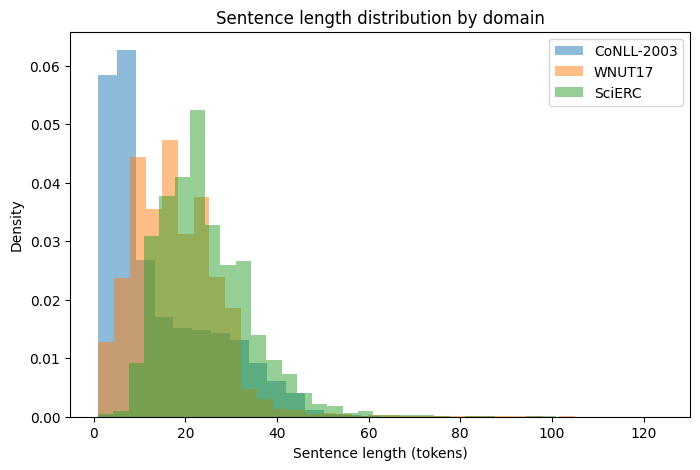

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for s, pairs in zip((conll_stats, wnut_stats, scierc_stats), (conll_pairs, wnut_pairs, scierc_pairs)):
    lengths = [len(tokens) for tokens, _ in pairs]
    ax.hist(lengths, bins=30, alpha=0.5, label=s["name"], density=True)
ax.set_xlabel("Sentence length (tokens)")
ax.set_ylabel("Density")
ax.set_title("Sentence length distribution by domain")
ax.legend()
plt.savefig("sentence_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
def jaccard(a, b):
    return len(a & b) / len(a | b)

pairs_to_compare = [
    ("CoNLL-2003", "WNUT17", conll_stats["vocab_set"], wnut_stats["vocab_set"]),
    ("CoNLL-2003", "SciERC", conll_stats["vocab_set"], scierc_stats["vocab_set"]),
    ("WNUT17", "SciERC", wnut_stats["vocab_set"], scierc_stats["vocab_set"]),
]

print("Vocabulary overlap (Jaccard similarity -- higher = more shared words):\n")
for name_a, name_b, vocab_a, vocab_b in pairs_to_compare:
    print(f"{name_a} vs {name_b}: {jaccard(vocab_a, vocab_b):.3f}")


Vocabulary overlap (Jaccard similarity -- higher = more shared words):

CoNLL-2003 vs WNUT17: 0.141
CoNLL-2003 vs SciERC: 0.095
WNUT17 vs SciERC: 0.100


## Step 5 — Spot-check a few SciERC sentences

Given SciERC's document-level offset quirk discussed earlier (see Qinyao's parsing notes), it's worth eyeballing a handful of tagged sentences to confirm the entity spans line up with real words before trusting the SciERC numbers above.


In [8]:
import random
random.seed(0)

for tokens, tags in random.sample(scierc_pairs, 5):
    tagged = " ".join(f"{tok}[{tag}]" if tag != "O" else tok for tok, tag in zip(tokens, tags))
    print(tagged)
    print("-" * 80)


The experimental results have shown significant improvements over the WI[B-Method] systems[I-Method] without the name[B-Task] identification[I-Task] capability .
--------------------------------------------------------------------------------
First , we transform the original instances into a new data[B-Method] representation[I-Method] using projections[B-OtherScientificTerm] learnt from pairwise[B-OtherScientificTerm] constraints[I-OtherScientificTerm] .
--------------------------------------------------------------------------------
We model shape[B-OtherScientificTerm] motion[I-OtherScientificTerm] as a rigid[B-Method] component[I-Method] -LRB- rotation[B-OtherScientificTerm] and translation[B-OtherScientificTerm] -RRB- combined with a non-rigid[B-OtherScientificTerm] deformation[I-OtherScientificTerm] .
--------------------------------------------------------------------------------
Finally , a measurement campaign is conducted and the functionality of the estimation[B-Method] meth

## Step 6 — Save outputs for the team


In [9]:
summary_df.to_csv("eda_summary_table.csv", index=False)

import shutil
from pathlib import Path
eda_dir = Path('/content/drive/MyDrive/AAI590/eda')
eda_dir.mkdir(parents=True, exist_ok=True)
for fname in ["eda_summary_table.csv", "entity_type_distribution.png", "entity_type_share.png", "sentence_length_distribution.png"]:
    shutil.copy(fname, eda_dir / fname)

print("Saved to Drive:", eda_dir)
print("Files:", sorted(p.name for p in eda_dir.glob("*")))


Saved to Drive: /content/drive/MyDrive/AAI590/eda
Files: ['eda_summary_table.csv', 'entity_type_distribution.png', 'entity_type_share.png', 'sentence_length_distribution.png']
